In [1]:
import os
import warnings
import joblib
import zipfile

import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    RandomizedSearchCV
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# Reproducibility
RANDOM_STATE = 42

# Paths
DATA_PATH = "data/final.csv"
MODEL_DIR = "models"

os.makedirs(MODEL_DIR, exist_ok=True)

print("Environment configured successfully.")
print(f"Random state: {RANDOM_STATE}")
print(f"Data path: {DATA_PATH}")
print(f"Model directory: {MODEL_DIR}")

Environment configured successfully.
Random state: 42
Data path: data/final.csv
Model directory: models


In [2]:
df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nDuplicate rows:", df.duplicated().sum())

DATASET INFORMATION
Shape: (30301, 14)

Columns:
['Address', 'Beds', 'Baths', 'Type', 'Area_in_sqft', 'Furnishing', 'Age_of_listing_in_days', 'Location', 'Latitude', 'Longitude', 'Distance_to_center', 'Geo_cluster', 'Location_score', 'Rent_per_sqft']

First 5 rows:


,Address,Beds,Baths,Type,Area_in_sqft,Furnishing,Age_of_listing_in_days,Location,Latitude,Longitude,Distance_to_center,Geo_cluster,Location_score,Rent_per_sqft
0,2508,2,2,2,1614,0,12,97,25.217623,55.278283,1.608245,11,0.358647,232.342007
1,962,2,2,1,1014,0,12,43,25.197978,55.360380,9.059846,1,0.131391,138.067061
2,1787,1,2,1,739,1,12,45,25.095619,55.138001,18.043374,3,0.833169,243.571042
3,1743,5,2,5,3010,1,12,46,25.126891,55.263874,8.658610,14,0.157768,99.667774
4,624,3,2,1,2271,1,12,38,24.987364,55.373964,26.238177,13,0.028584,46.235139



Data types:
Address                     int64
Beds                        int64
Baths                       int64
Type                        int64
Area_in_sqft                int64
Furnishing                  int64
Age_of_listing_in_days      int64
Location                    int64
Latitude                  float64
Longitude                 float64
Distance_to_center        float64
Geo_cluster                 int64
Location_score            float64
Rent_per_sqft             float64
dtype: object

Missing values:
Series([], dtype: int64)

Duplicate rows: 0


In [3]:
TARGET = "Rent_per_sqft"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' was not found.")

print("\nTarget statistics:")
print(df[TARGET].describe())

if (df[TARGET] <= 0).any():
    print("\nWARNING: Non-positive target values detected.")
else:
    print("\nTarget validation passed: all values are positive.")


Target statistics:
count    30301.000000
mean       131.332439
std         68.184429
min          0.232000
25%         85.375929
50%        119.081372
75%        159.176030
max        962.824285
Name: Rent_per_sqft, dtype: float64

Target validation passed: all values are positive.


In [4]:
RAW_FEATURES = [
    "Location",
    "Latitude",
    "Longitude",
    "Furnishing",
    "Beds",
    "Type"
]

required_columns = RAW_FEATURES + [TARGET]

model_df = df[required_columns].copy()


In [5]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print(f"Total samples: {len(model_df):,}")
print(f"Training samples: {len(train_df):,}")
print(f"Testing samples: {len(test_df):,}")

print("\nTarget statistics:")
print(f"Train mean: {train_df[TARGET].mean():.2f}")
print(f"Test mean:  {test_df[TARGET].mean():.2f}")
print(f"Train std:  {train_df[TARGET].std():.2f}")
print(f"Test std:   {test_df[TARGET].std():.2f}")

TRAIN / TEST SPLIT
Total samples: 30,301
Training samples: 24,240
Testing samples: 6,061

Target statistics:
Train mean: 131.45
Test mean:  130.87
Train std:  68.60
Test std:   66.51


looking at the mean and std values we can say that if the model's RMSE is close to 68, it's doing poorly (just predicting the average) also if the model's RMSE is much lower (e.g., 30-40), it's successfully capturing patterns 

In [6]:
DUBAI_CENTER = (25.2048, 55.2708)
EARTH_RADIUS = 6371.0
N_CLUSTERS = 15


def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate great-circle distance in kilometers.
    """
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(a))


def add_distance_to_center(train_data, test_data):
    """
    Add distance from Dubai center to both datasets.
    No target information is used.
    """

    train_data = train_data.copy()
    test_data = test_data.copy()

    train_data["Distance_to_center"] = haversine(
        train_data["Latitude"].values,
        train_data["Longitude"].values,
        DUBAI_CENTER[0],
        DUBAI_CENTER[1]
    )

    test_data["Distance_to_center"] = haversine(
        test_data["Latitude"].values,
        test_data["Longitude"].values,
        DUBAI_CENTER[0],
        DUBAI_CENTER[1]
    )

    return train_data, test_data


def add_geo_cluster(train_data, test_data):
    """
    Fit KMeans ONLY on training coordinates.
    Apply the fitted model to the test coordinates.
    """

    train_data = train_data.copy()
    test_data = test_data.copy()

    kmeans = KMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        n_init=10
    )

    train_data["Geo_cluster"] = kmeans.fit_predict(
        train_data[["Latitude", "Longitude"]]
    )

    test_data["Geo_cluster"] = kmeans.predict(
        test_data[["Latitude", "Longitude"]]
    )

    return train_data, test_data, kmeans


def calculate_location_score(train_data, test_data):
    """
    Calculate Location_score using ONLY training target information.

    The score is based on:
    1. Median Rent_per_sqft by Location
    2. Top 5 locations
    3. Relative location weights
    4. Geographic distance to location centers

    The test set NEVER contributes target information.
    """

    train_data = train_data.copy()
    test_data = test_data.copy()



    top_locations = (
        train_data
        .groupby("Location")[TARGET]
        .median()
        .sort_values(ascending=False)
        .head(5)
    )

    weights = top_locations / top_locations.sum()



    location_centers = (
        train_data
        .groupby("Location")[["Latitude", "Longitude"]]
        .mean()
    )



    def score_dataframe(data):
        scores = np.zeros(len(data))

        for location, weight in weights.items():

            center_lat = location_centers.loc[
                location, "Latitude"
            ]

            center_lon = location_centers.loc[
                location, "Longitude"
            ]

            distance = haversine(
                data["Latitude"].values,
                data["Longitude"].values,
                center_lat,
                center_lon
            )

            scores += weight * (1 / (distance + 1))

        return scores

    train_scores = score_dataframe(train_data)
    test_scores = score_dataframe(test_data)


    score_min = train_scores.min()
    score_max = train_scores.max()

    if score_max == score_min:
        train_scores = np.zeros_like(train_scores)
        test_scores = np.zeros_like(test_scores)
    else:
        train_scores = (
            (train_scores - score_min)
            / (score_max - score_min)
        )

        test_scores = (
            (test_scores - score_min)
            / (score_max - score_min)
        )

    train_data["Location_score"] = train_scores
    test_data["Location_score"] = test_scores

    return (
        train_data,
        test_data,
        weights,
        location_centers,
        score_min,
        score_max
    )



train_geo, test_geo = add_distance_to_center(
    train_df,
    test_df
)

train_geo, test_geo, kmeans = add_geo_cluster(
    train_geo,
    test_geo
)

(
    train_geo,
    test_geo,
    location_weights,
    location_centers,
    location_score_min,
    location_score_max
) = calculate_location_score(
    train_geo,
    test_geo
)

print("Geographic feature engineering complete.")

print("\nGenerated features:")
print([
    "Distance_to_center",
    "Geo_cluster",
    "Location_score"
])

print("\nTraining sample:")
display(
    train_geo[
        [
            "Location",
            "Latitude",
            "Longitude",
            "Distance_to_center",
            "Geo_cluster",
            "Location_score"
        ]
    ].head()
)


Geographic feature engineering complete.

Generated features:
['Distance_to_center', 'Geo_cluster', 'Location_score']

Training sample:


,Location,Latitude,Longitude,Distance_to_center,Geo_cluster,Location_score
0,110,25.010851,55.288876,21.642761,4,0.060980
1,50,25.078641,55.135252,19.569253,1,0.534242
2,106,25.015106,55.450381,27.782201,0,0.017384
3,75,25.055945,55.207465,17.737523,5,0.143414
4,46,25.098721,55.253940,11.916897,7,0.134167


In [7]:
# ============================================================
# CELL 6B — CONSISTENT CATEGORICAL ENCODING
# ============================================================

from sklearn.preprocessing import OrdinalEncoder

CATEGORICAL_FEATURES = [
    "Furnishing",
    "Type"
]

# Copy data
train_processed = train_geo.copy()
test_processed = test_geo.copy()

# Fit encoder ONLY on training data
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train_processed[CATEGORICAL_FEATURES] = encoder.fit_transform(
    train_processed[CATEGORICAL_FEATURES].astype(str)
)

test_processed[CATEGORICAL_FEATURES] = encoder.transform(
    test_processed[CATEGORICAL_FEATURES].astype(str)
)

print("Categorical encoding completed.")

print("\nEncoder categories:")
for feature, categories in zip(
    CATEGORICAL_FEATURES,
    encoder.categories_
):
    print(f"{feature}: {list(categories)}")

print("\nEncoded training sample:")
display(
    train_processed[
        CATEGORICAL_FEATURES
    ].head()
)

Categorical encoding completed.

Encoder categories:
Furnishing: ['0', '1']
Type: ['0', '1', '2', '3', '4', '5']

Encoded training sample:


,Furnishing,Type
0,1.0,5.0
1,0.0,1.0
2,1.0,5.0
3,1.0,4.0
4,1.0,1.0


In [8]:
# ============================================================
# CELL 6C — CREATE INTERACTION FEATURES
# ============================================================

def add_interaction_features(data):
    """
    Add interpretable interaction features.

    The categorical variables have already been encoded
    consistently using the training-fitted encoder.
    """

    data = data.copy()

    # Location quality × number of bedrooms
    data["LocationScore_Beds"] = (
        data["Location_score"] * data["Beds"]
    )

    # Distance × number of bedrooms
    data["Distance_Beds"] = (
        data["Distance_to_center"] * data["Beds"]
    )

    # Location quality × furnishing
    data["LocationScore_Furnishing"] = (
        data["Location_score"] * data["Furnishing"]
    )

    # Distance × property type
    data["Distance_Type"] = (
        data["Distance_to_center"] * data["Type"]
    )

    return data


train_processed = add_interaction_features(
    train_processed
)

test_processed = add_interaction_features(
    test_processed
)

INTERACTION_FEATURES = [
    "LocationScore_Beds",
    "Distance_Beds",
    "LocationScore_Furnishing",
    "Distance_Type"
]

print("Interaction features created:")
for feature in INTERACTION_FEATURES:
    print(f"  - {feature}")

Interaction features created:
  - LocationScore_Beds
  - Distance_Beds
  - LocationScore_Furnishing
  - Distance_Type


In [9]:
# ============================================================
# CELL 7 — EXPERIMENTAL FEATURE SETS
# ============================================================

FEATURE_SETS = {

    # Original approach from your notebook
    "Top5": [
        "Location_score",
        "Distance_to_center",
        "Beds",
        "Furnishing",
        "Type"
    ],

    # Add geographic clustering
    "Geo6": [
        "Location_score",
        "Distance_to_center",
        "Beds",
        "Furnishing",
        "Type",
        "Geo_cluster"
    ],

    # Add raw geographic coordinates
    "Geo8": [
        "Location_score",
        "Distance_to_center",
        "Beds",
        "Furnishing",
        "Type",
        "Geo_cluster",
        "Latitude",
        "Longitude"
    ],

    # Full engineered feature set
    "Interaction": [
        "Location_score",
        "Distance_to_center",
        "Beds",
        "Furnishing",
        "Type",
        "Geo_cluster",
        "Latitude",
        "Longitude",
        "LocationScore_Beds",
        "Distance_Beds",
        "LocationScore_Furnishing",
        "Distance_Type"
    ]
}

print("=" * 70)
print("FEATURE SETS")
print("=" * 70)

for name, features in FEATURE_SETS.items():
    print(f"\n{name} ({len(features)} features)")
    for feature in features:
        print(f"  - {feature}")

FEATURE SETS

Top5 (5 features)
  - Location_score
  - Distance_to_center
  - Beds
  - Furnishing
  - Type

Geo6 (6 features)
  - Location_score
  - Distance_to_center
  - Beds
  - Furnishing
  - Type
  - Geo_cluster

Geo8 (8 features)
  - Location_score
  - Distance_to_center
  - Beds
  - Furnishing
  - Type
  - Geo_cluster
  - Latitude
  - Longitude

Interaction (12 features)
  - Location_score
  - Distance_to_center
  - Beds
  - Furnishing
  - Type
  - Geo_cluster
  - Latitude
  - Longitude
  - LocationScore_Beds
  - Distance_Beds
  - LocationScore_Furnishing
  - Distance_Type


In [10]:
# ============================================================
# CELL 8 — DEFINE FOUR MODEL FAMILIES
# ============================================================

models = {

    "RandomForest": RandomForestRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBRegressor(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

print("Models configured:")
for name in models:
    print(f"  - {name}")

Models configured:
  - RandomForest
  - GradientBoosting
  - XGBoost
  - LightGBM


In [11]:
# ============================================================
# CELL 9 — EVALUATION FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):
    """
    Calculate evaluation metrics on the original target scale.
    """

    return {
        "R2": r2_score(y_true, y_pred),

        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),

        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "MedianAE": median_absolute_error(
            y_true,
            y_pred
        )
    }


def print_metrics(metrics):
    print(
        f"R² = {metrics['R2']:.4f} | "
        f"RMSE = {metrics['RMSE']:.3f} | "
        f"MAE = {metrics['MAE']:.3f} | "
        f"MedianAE = {metrics['MedianAE']:.3f}"
    )

In [12]:
# ============================================================
# CELL 10 — FOUR-MODEL × FEATURE-SET COMPARISON
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

screening_results = []

print("=" * 70)
print("STARTING MODEL SCREENING")
print("=" * 70)

for model_name, model in models.items():

    for feature_set_name, feature_list in FEATURE_SETS.items():

        print(
            f"\nTraining {model_name} | "
            f"{feature_set_name}"
        )

        X_train_exp = train_processed[feature_list]
        y_train_exp = train_processed[TARGET]

        scoring = {
            "R2": "r2",
            "RMSE": "neg_root_mean_squared_error",
            "MAE": "neg_mean_absolute_error"
        }

        cv_results = cross_validate(
            model,
            X_train_exp,
            y_train_exp,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        mean_r2 = cv_results["test_R2"].mean()
        std_r2 = cv_results["test_R2"].std()

        mean_rmse = -cv_results[
            "test_RMSE"
        ].mean()

        mean_mae = -cv_results[
            "test_MAE"
        ].mean()

        screening_results.append({
            "Model": model_name,
            "Feature_Set": feature_set_name,
            "R2_Mean": mean_r2,
            "R2_STD": std_r2,
            "RMSE_Mean": mean_rmse,
            "MAE_Mean": mean_mae,
            "Num_Features": len(feature_list)
        })

        print(
            f"  R²: {mean_r2:.4f} ± {std_r2:.4f}"
        )
        print(
            f"  RMSE: {mean_rmse:.3f}"
        )
        print(
            f"  MAE: {mean_mae:.3f}"
        )


screening_df = pd.DataFrame(screening_results)

screening_df = screening_df.sort_values(
    by="R2_Mean",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL SCREENING RESULTS")
print("=" * 70)

display(screening_df)

STARTING MODEL SCREENING

Training RandomForest | Top5


  R²: 0.5704 ± 0.0249
  RMSE: 44.953
  MAE: 26.859

Training RandomForest | Geo6
  R²: 0.5706 ± 0.0249
  RMSE: 44.942
  MAE: 26.850

Training RandomForest | Geo8
  R²: 0.5694 ± 0.0259
  RMSE: 45.003
  MAE: 26.840

Training RandomForest | Interaction
  R²: 0.5737 ± 0.0255
  RMSE: 44.775
  MAE: 26.777

Training GradientBoosting | Top5
  R²: 0.5683 ± 0.0205
  RMSE: 45.066
  MAE: 27.199

Training GradientBoosting | Geo6
  R²: 0.5693 ± 0.0200
  RMSE: 45.011
  MAE: 27.154

Training GradientBoosting | Geo8
  R²: 0.5702 ± 0.0205
  RMSE: 44.967
  MAE: 27.019

Training GradientBoosting | Interaction
  R²: 0.5739 ± 0.0217
  RMSE: 44.770
  MAE: 26.869

Training XGBoost | Top5
  R²: 0.5717 ± 0.0234
  RMSE: 44.886
  MAE: 26.735

Training XGBoost | Geo6
  R²: 0.5716 ± 0.0234
  RMSE: 44.887
  MAE: 26.720

Training XGBoost | Geo8
  R²: 0.5705 ± 0.0231
  RMSE: 44.947
  MAE: 26.701

Training XGBoost | Interaction
  R²: 0.5701 ± 0.0216
  RMSE: 44.967
  MAE: 26.699

Training LightGBM | Top5
  R²: 0.5725 ± 

,Model,Feature_Set,R2_Mean,R2_STD,RMSE_Mean,MAE_Mean,Num_Features
0,GradientBoosting,Interaction,0.573896,0.021685,44.770056,26.869250,12
1,RandomForest,Interaction,0.573738,0.025514,44.774699,26.777461,12
2,LightGBM,Interaction,0.572986,0.024121,44.815547,26.794059,12
3,LightGBM,Top5,0.572502,0.024080,44.840699,26.789209,5
4,LightGBM,Geo8,0.572328,0.025283,44.848753,26.769492,8
5,LightGBM,Geo6,0.572111,0.023849,44.861558,26.761394,6
6,XGBoost,Top5,0.571660,0.023412,44.886285,26.734649,5
7,XGBoost,Geo6,0.571642,0.023432,44.887213,26.719805,6
8,RandomForest,Geo6,0.570564,0.024897,44.942253,26.849868,6
9,XGBoost,Geo8,0.570511,0.023111,44.946653,26.700766,8


In [13]:
# ============================================================
# CELL 11 — RAW TARGET VS LOG TARGET
# ============================================================

y_train_raw = train_processed[TARGET].values

y_train_log = np.log1p(
    y_train_raw
)

print("Target transformation comparison:")
print(f"Raw target mean: {y_train_raw.mean():.3f}")
print(f"Log target mean: {y_train_log.mean():.3f}")

Target transformation comparison:
Raw target mean: 131.448
Log target mean: 4.771


In [14]:
# Top candidates from raw-target screening
TOP_CANDIDATES = screening_df.head(4)

print("\nCandidates selected for log-target experiment:")
display(TOP_CANDIDATES)


Candidates selected for log-target experiment:


,Model,Feature_Set,R2_Mean,R2_STD,RMSE_Mean,MAE_Mean,Num_Features
0,GradientBoosting,Interaction,0.573896,0.021685,44.770056,26.869250,12
1,RandomForest,Interaction,0.573738,0.025514,44.774699,26.777461,12
2,LightGBM,Interaction,0.572986,0.024121,44.815547,26.794059,12
3,LightGBM,Top5,0.572502,0.024080,44.840699,26.789209,5


In [15]:
log_results = []

for _, row in TOP_CANDIDATES.iterrows():

    model_name = row["Model"]
    feature_set_name = row["Feature_Set"]

    model = models[model_name]
    feature_list = FEATURE_SETS[feature_set_name]

    X_train_exp = train_processed[feature_list]

    cv_log = KFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    fold_r2 = []
    fold_rmse = []
    fold_mae = []

    for train_idx, valid_idx in cv_log.split(
        X_train_exp
    ):

        X_fold_train = X_train_exp.iloc[train_idx]
        X_fold_valid = X_train_exp.iloc[valid_idx]

        y_fold_train = y_train_log[train_idx]
        y_fold_valid_raw = y_train_raw[valid_idx]

        # Train using logarithmic target
        model.fit(
            X_fold_train,
            y_fold_train
        )

        # Predict on log scale
        pred_log = model.predict(
            X_fold_valid
        )

        # Return to original AED/sqft scale
        pred_raw = np.expm1(pred_log)

        # Prevent impossible negative predictions
        pred_raw = np.maximum(
            pred_raw,
            0
        )

        fold_r2.append(
            r2_score(
                y_fold_valid_raw,
                pred_raw
            )
        )

        fold_rmse.append(
            np.sqrt(
                mean_squared_error(
                    y_fold_valid_raw,
                    pred_raw
                )
            )
        )

        fold_mae.append(
            mean_absolute_error(
                y_fold_valid_raw,
                pred_raw
            )
        )

    log_results.append({
        "Model": model_name,
        "Feature_Set": feature_set_name,
        "Target": "log1p",
        "R2_Mean": np.mean(fold_r2),
        "R2_STD": np.std(fold_r2),
        "RMSE_Mean": np.mean(fold_rmse),
        "MAE_Mean": np.mean(fold_mae)
    })

log_results_df = pd.DataFrame(log_results)

print("=" * 70)
print("LOG-TARGET RESULTS")
print("=" * 70)

display(
    log_results_df.sort_values(
        "R2_Mean",
        ascending=False
    )
)

LOG-TARGET RESULTS


,Model,Feature_Set,Target,R2_Mean,R2_STD,RMSE_Mean,MAE_Mean
2,LightGBM,Interaction,log1p,0.568020,0.023852,45.075466,26.189456
1,RandomForest,Interaction,log1p,0.565687,0.024286,45.196644,26.250998
0,GradientBoosting,Interaction,log1p,0.565175,0.020038,45.226774,26.278708
3,LightGBM,Top5,log1p,0.564543,0.024270,45.255866,26.218863


In [16]:
# ============================================================
# CELL 12 — SELECT BEST TARGET REPRESENTATION
# ============================================================

raw_candidates = screening_df.copy()

raw_candidates["Target"] = "raw"

log_candidates = log_results_df.copy()

comparison_df = pd.concat(
    [
        raw_candidates[
            [
                "Model",
                "Feature_Set",
                "Target",
                "R2_Mean",
                "R2_STD",
                "RMSE_Mean",
                "MAE_Mean"
            ]
        ],
        log_candidates
    ],
    ignore_index=True
)

comparison_df = comparison_df.sort_values(
    by="R2_Mean",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("RAW VS LOG TARGET COMPARISON")
print("=" * 70)

display(comparison_df)

RAW VS LOG TARGET COMPARISON


,Model,Feature_Set,Target,R2_Mean,R2_STD,RMSE_Mean,MAE_Mean
0,GradientBoosting,Interaction,raw,0.573896,0.021685,44.770056,26.869250
1,RandomForest,Interaction,raw,0.573738,0.025514,44.774699,26.777461
2,LightGBM,Interaction,raw,0.572986,0.024121,44.815547,26.794059
3,LightGBM,Top5,raw,0.572502,0.024080,44.840699,26.789209
4,LightGBM,Geo8,raw,0.572328,0.025283,44.848753,26.769492
5,LightGBM,Geo6,raw,0.572111,0.023849,44.861558,26.761394
6,XGBoost,Top5,raw,0.571660,0.023412,44.886285,26.734649
7,XGBoost,Geo6,raw,0.571642,0.023432,44.887213,26.719805
8,RandomForest,Geo6,raw,0.570564,0.024897,44.942253,26.849868
9,XGBoost,Geo8,raw,0.570511,0.023111,44.946653,26.700766


In [17]:
best_candidate = comparison_df.iloc[0]

BEST_MODEL_NAME = best_candidate["Model"]
BEST_FEATURE_SET_NAME = best_candidate["Feature_Set"]
BEST_TARGET_TYPE = best_candidate["Target"]

BEST_FEATURES = FEATURE_SETS[
    BEST_FEATURE_SET_NAME
]

print("\nSelected candidate:")
print(f"Model: {BEST_MODEL_NAME}")
print(f"Feature set: {BEST_FEATURE_SET_NAME}")
print(f"Target: {BEST_TARGET_TYPE}")
print(f"CV R²: {best_candidate['R2_Mean']:.4f}")
print(f"CV RMSE: {best_candidate['RMSE_Mean']:.3f}")

print("\nFeatures:")
for feature in BEST_FEATURES:
    print(f"  - {feature}")


Selected candidate:
Model: GradientBoosting
Feature set: Interaction
Target: raw
CV R²: 0.5739
CV RMSE: 44.770

Features:
  - Location_score
  - Distance_to_center
  - Beds
  - Furnishing
  - Type
  - Geo_cluster
  - Latitude
  - Longitude
  - LocationScore_Beds
  - Distance_Beds
  - LocationScore_Furnishing
  - Distance_Type


In [18]:
# ============================================================
# CELL 13 — FINALIST 5-FOLD CROSS-VALIDATION
# ============================================================

final_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

finalist_model = models[BEST_MODEL_NAME]

X_finalist = train_processed[
    BEST_FEATURES
]

if BEST_TARGET_TYPE == "log1p":
    y_finalist = np.log1p(
        train_processed[TARGET].values
    )
else:
    y_finalist = train_processed[
        TARGET
    ].values


cv_scores = cross_validate(
    finalist_model,
    X_finalist,
    y_finalist,
    cv=final_cv,
    scoring={
        "R2": "r2",
        "RMSE": "neg_root_mean_squared_error",
        "MAE": "neg_mean_absolute_error"
    },
    n_jobs=-1,
    return_train_score=False
)

print("=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

print(
    f"R²: "
    f"{cv_scores['test_R2'].mean():.4f} "
    f"± {cv_scores['test_R2'].std():.4f}"
)

print(
    f"RMSE (model scale): "
    f"{-cv_scores['test_RMSE'].mean():.4f}"
)

print(
    f"MAE (model scale): "
    f"{-cv_scores['test_MAE'].mean():.4f}"
)

5-FOLD CROSS-VALIDATION
R²: 0.5698 ± 0.0265
RMSE (model scale): 44.9783
MAE (model scale): 26.8675


In [19]:
# ============================================================
# CELL 14 — RANDOMIZED HYPERPARAMETER SEARCH
# ============================================================

from scipy.stats import randint, uniform

if BEST_MODEL_NAME == "RandomForest":

    tuning_model = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    param_distributions = {
        "n_estimators": randint(80, 201),
        "max_depth": [None, 10, 15, 20, 25],
        "min_samples_split": randint(2, 10),
        "min_samples_leaf": randint(1, 5),
        "max_features": ["sqrt", "log2", 1.0]
    }

elif BEST_MODEL_NAME == "GradientBoosting":

    tuning_model = GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )

    param_distributions = {
        "n_estimators": randint(80, 201),
        "learning_rate": uniform(0.02, 0.13),
        "max_depth": randint(2, 7),
        "min_samples_leaf": randint(1, 6),
        "subsample": uniform(0.7, 0.3)
    }

elif BEST_MODEL_NAME == "XGBoost":

    tuning_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

    param_distributions = {
        "n_estimators": randint(80, 251),
        "max_depth": randint(3, 9),
        "learning_rate": uniform(0.02, 0.13),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3),
        "min_child_weight": randint(1, 8),
        "gamma": uniform(0.0, 0.5)
    }

elif BEST_MODEL_NAME == "LightGBM":

    tuning_model = LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )

    param_distributions = {
        "n_estimators": randint(80, 251),
        "learning_rate": uniform(0.02, 0.13),
        "num_leaves": randint(15, 64),
        "max_depth": [-1, 5, 7, 10],
        "min_child_samples": randint(10, 50),
        "subsample": uniform(0.7, 0.3),
        "colsample_bytree": uniform(0.7, 0.3)
    }

else:
    raise ValueError(
        f"Unknown model: {BEST_MODEL_NAME}"
    )


random_search = RandomizedSearchCV(
    estimator=tuning_model,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="r2",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

X_tuning = train_processed[
    BEST_FEATURES
]

if BEST_TARGET_TYPE == "log1p":
    y_tuning = np.log1p(
        train_processed[TARGET].values
    )
else:
    y_tuning = train_processed[
        TARGET
    ].values

print("=" * 70)
print("STARTING RANDOMIZED SEARCH")
print("=" * 70)

random_search.fit(
    X_tuning,
    y_tuning
)

print("\nBest parameters:")
for parameter, value in random_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(
    f"\nBest CV R²: "
    f"{random_search.best_score_:.4f}"
)

tuned_model = random_search.best_estimator_

STARTING RANDOMIZED SEARCH
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best parameters:
  learning_rate: 0.1128974699510081
  max_depth: 6
  min_samples_leaf: 5
  n_estimators: 80
  subsample: 0.9864595841989582

Best CV R²: 0.5780


In [20]:
# ============================================================
# CELL 15 — FINAL TEST-SET EVALUATION
# ============================================================

X_test_final = test_processed[
    BEST_FEATURES
]

y_test_original = test_processed[
    TARGET
].values

# Train model has already been fitted by RandomizedSearchCV
test_predictions_model_scale = tuned_model.predict(
    X_test_final
)

# Convert back to original target scale
if BEST_TARGET_TYPE == "log1p":

    y_test_predictions = np.expm1(
        test_predictions_model_scale
    )

else:

    y_test_predictions = (
        test_predictions_model_scale
    )

# Prevent impossible negative predictions
y_test_predictions = np.maximum(
    y_test_predictions,
    0
)

test_metrics = calculate_metrics(
    y_test_original,
    y_test_predictions
)

print("=" * 70)
print("FINAL TEST-SET PERFORMANCE")
print("=" * 70)

print(f"Model: {BEST_MODEL_NAME}")
print(f"Feature set: {BEST_FEATURE_SET_NAME}")
print(f"Target representation: {BEST_TARGET_TYPE}")

print("\nMetrics:")
print_metrics(test_metrics)

FINAL TEST-SET PERFORMANCE
Model: GradientBoosting
Feature set: Interaction
Target representation: raw

Metrics:
R² = 0.5920 | RMSE = 42.483 | MAE = 25.862 | MedianAE = 16.586


In [21]:
# ============================================================
# CELL 17 — RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_test_original
    - y_test_predictions
)

evaluation_df = pd.DataFrame({
    "Actual": y_test_original,
    "Predicted": y_test_predictions,
    "Residual": residuals,
    "Absolute_Error": np.abs(residuals)
})

print("=" * 70)
print("RESIDUAL SUMMARY")
print("=" * 70)

print(
    evaluation_df[
        [
            "Actual",
            "Predicted",
            "Residual",
            "Absolute_Error"
        ]
    ].describe()
)

RESIDUAL SUMMARY
            Actual    Predicted     Residual  Absolute_Error
count  6061.000000  6061.000000  6061.000000     6061.000000
mean    130.869417   131.105390    -0.235972       25.862364
std      66.513254    51.168593    42.485499       33.706099
min       6.921199    13.876620  -282.287661        0.008810
25%      85.714286    92.663799   -19.064360        7.048833
50%     119.346734   129.351472    -2.743884       16.586147
75%     158.526135   160.849098    13.727652       32.851008
max     946.969697   478.781241   619.335954      619.335954


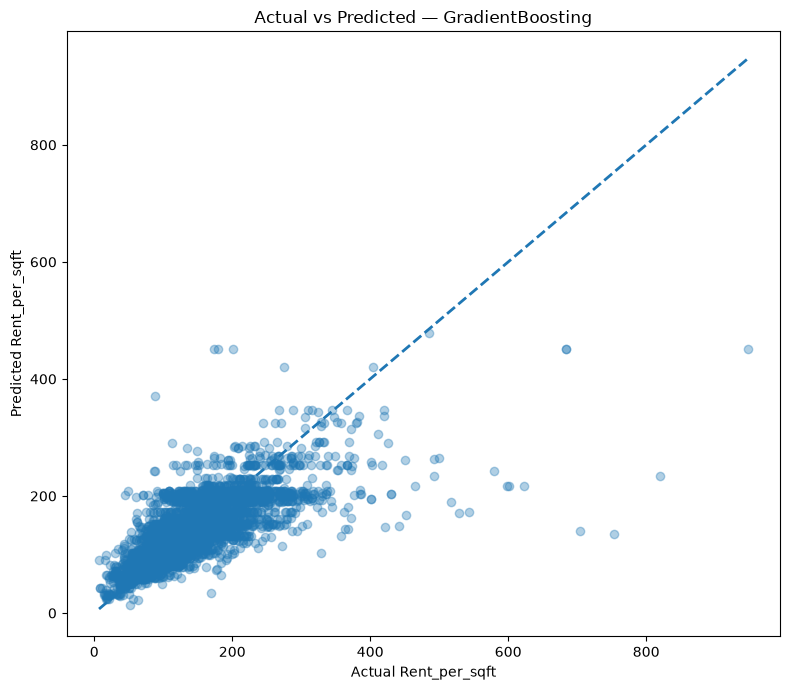

In [22]:
# ============================================================
# CELL 18 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test_original,
    y_test_predictions,
    alpha=0.35
)

minimum = min(
    y_test_original.min(),
    y_test_predictions.min()
)

maximum = max(
    y_test_original.max(),
    y_test_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Rent_per_sqft")
plt.ylabel("Predicted Rent_per_sqft")

plt.title(
    f"Actual vs Predicted — "
    f"{BEST_MODEL_NAME}"
)

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

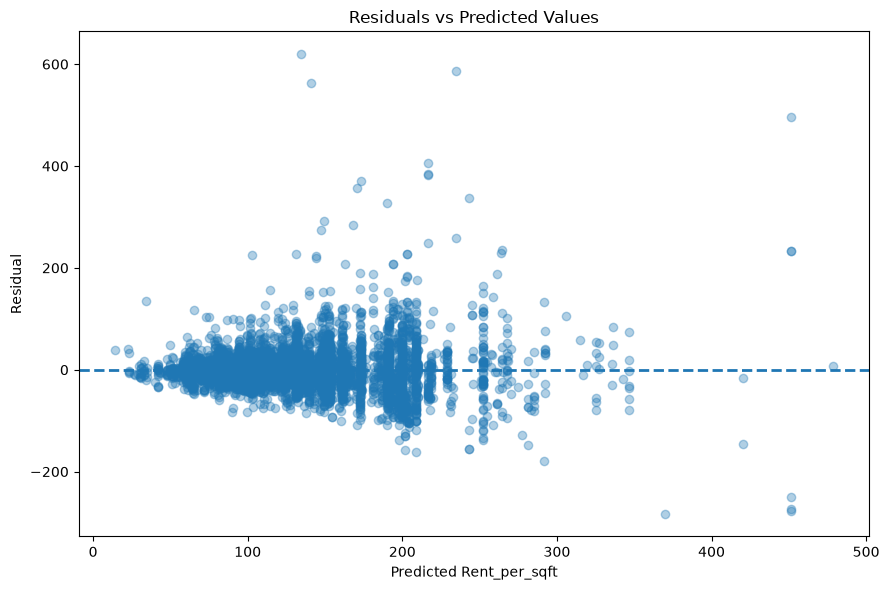

In [23]:
# ============================================================
# CELL 19 — RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_predictions,
    residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Rent_per_sqft")
plt.ylabel("Residual")

plt.title("Residuals vs Predicted Values")

plt.tight_layout()

plt.savefig(
    "residuals_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

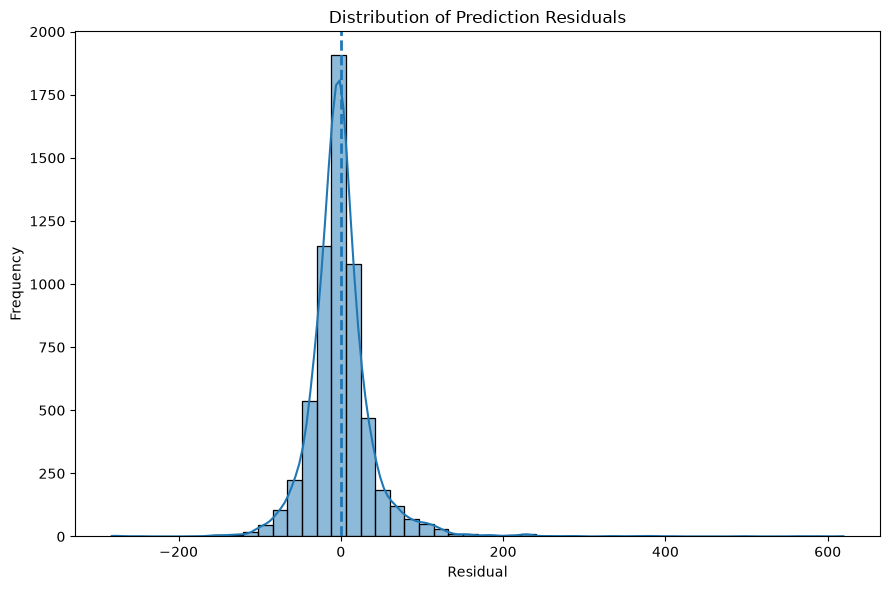

In [24]:
# ============================================================
# CELL 20 — RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Distribution of Prediction Residuals")

plt.tight_layout()

plt.savefig(
    "residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

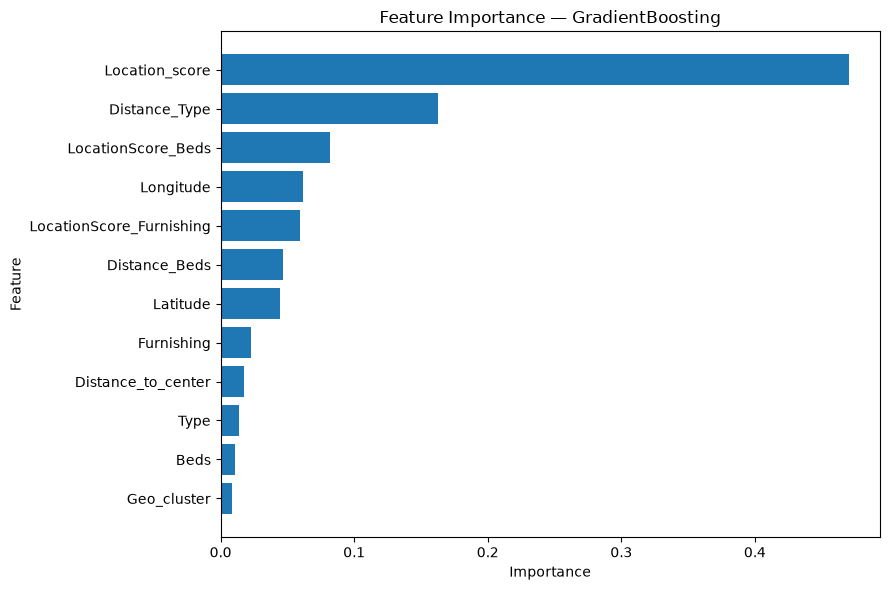

In [25]:
# ============================================================
# CELL 21 — FEATURE IMPORTANCE
# ============================================================

importance = tuned_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": BEST_FEATURES,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    f"Feature Importance — {BEST_MODEL_NAME}"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

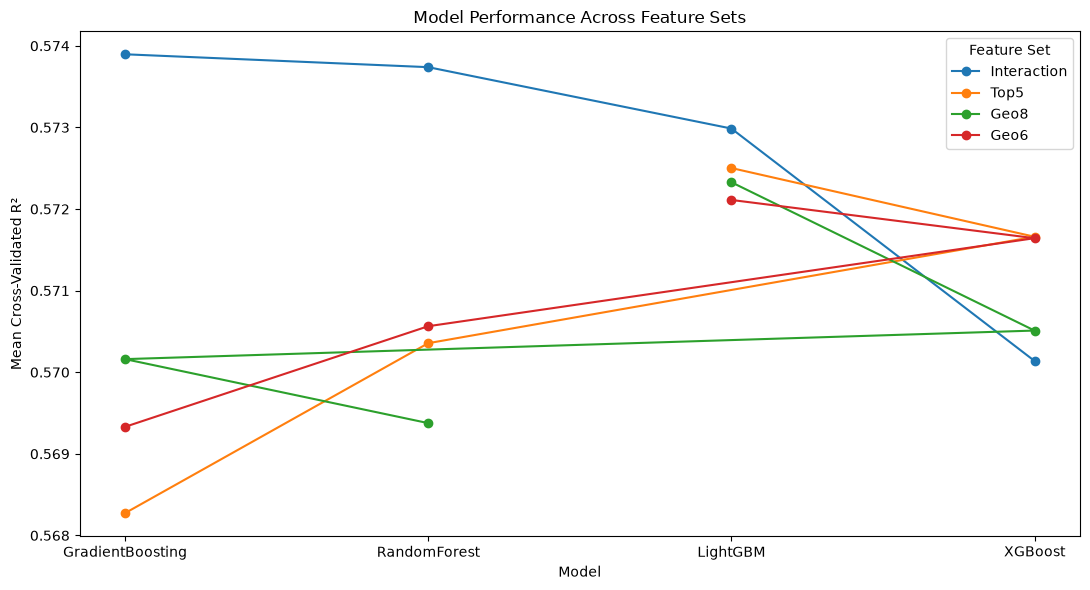

In [26]:
# ============================================================
# CELL 22 — MODEL COMPARISON
# ============================================================

plot_df = screening_df.copy()

plt.figure(figsize=(11, 6))

for feature_set in plot_df[
    "Feature_Set"
].unique():

    subset = plot_df[
        plot_df["Feature_Set"] == feature_set
    ]

    plt.plot(
        subset["Model"],
        subset["R2_Mean"],
        marker="o",
        label=feature_set
    )

plt.xlabel("Model")
plt.ylabel("Mean Cross-Validated R²")

plt.title(
    "Model Performance Across Feature Sets"
)

plt.legend(
    title="Feature Set"
)

plt.tight_layout()

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

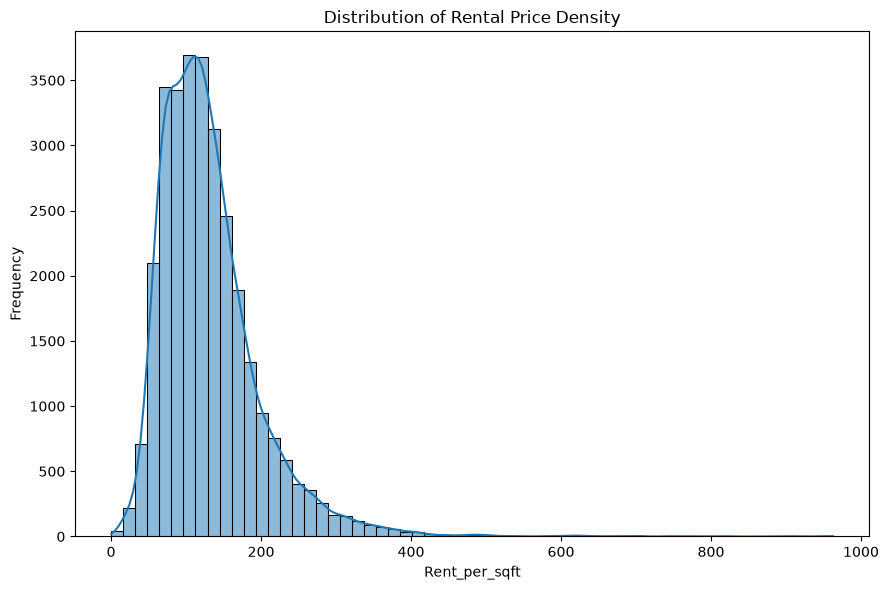

In [27]:
# ============================================================
# CELL 23 — TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

sns.histplot(
    model_df[TARGET],
    bins=60,
    kde=True
)

plt.xlabel("Rent_per_sqft")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Rental Price Density"
)

plt.tight_layout()

plt.savefig(
    "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
# ============================================================
# CELL 24 — SAVE MODEL AND PREPROCESSING ARTIFACTS
# ============================================================

print("=" * 70)
print("SAVING MODEL ARTIFACTS")
print("=" * 70)

# Save tuned model
joblib.dump(
    tuned_model,
    f"{MODEL_DIR}/final_model.pkl"
)

# Save categorical encoder
joblib.dump(
    encoder,
    f"{MODEL_DIR}/categorical_encoder.pkl"
)

# Save KMeans
joblib.dump(
    kmeans,
    f"{MODEL_DIR}/geo_kmeans.pkl"
)

# Save geographic metadata
geo_metadata = {
    "location_weights": location_weights.to_dict(),
    "location_centers": location_centers.to_dict(),
    "location_score_min": location_score_min,
    "location_score_max": location_score_max,
    "dubai_center": DUBAI_CENTER,
    "n_clusters": N_CLUSTERS
}

joblib.dump(
    geo_metadata,
    f"{MODEL_DIR}/geo_metadata.pkl"
)

# Save feature list
with open(
    f"{MODEL_DIR}/features_list.txt",
    "w",
    encoding="utf-8"
) as f:

    for feature in BEST_FEATURES:
        f.write(feature + "\n")

print("✅ final_model.pkl")
print("✅ categorical_encoder.pkl")
print("✅ geo_kmeans.pkl")
print("✅ geo_metadata.pkl")
print("✅ features_list.txt")

SAVING MODEL ARTIFACTS
✅ final_model.pkl
✅ categorical_encoder.pkl
✅ geo_kmeans.pkl
✅ geo_metadata.pkl
✅ features_list.txt


In [29]:
# ============================================================
# CELL 25 — SAVE MODEL METADATA
# ============================================================

model_info = {
    "model_type": BEST_MODEL_NAME,
    "feature_set": BEST_FEATURE_SET_NAME,
    "target": TARGET,
    "target_transformation": BEST_TARGET_TYPE,
    "features": BEST_FEATURES,
    "test_r2": test_metrics["R2"],
    "test_rmse": test_metrics["RMSE"],
    "test_mae": test_metrics["MAE"],
    "test_median_ae": test_metrics["MedianAE"],
    "random_state": RANDOM_STATE,
    "n_clusters": N_CLUSTERS,
    "best_parameters": random_search.best_params_
}

joblib.dump(
    model_info,
    f"{MODEL_DIR}/model_info.pkl"
)

with open(
    f"{MODEL_DIR}/model_info.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "DUBAI RENTAL PRICE DENSITY MODEL\n"
    )
    f.write("=" * 60 + "\n\n")

    f.write(
        f"Model: {BEST_MODEL_NAME}\n"
    )

    f.write(
        f"Feature Set: {BEST_FEATURE_SET_NAME}\n"
    )

    f.write(
        f"Target: {TARGET}\n"
    )

    f.write(
        f"Target Transformation: "
        f"{BEST_TARGET_TYPE}\n\n"
    )

    f.write(
        f"Test R²: "
        f"{test_metrics['R2']:.6f}\n"
    )

    f.write(
        f"Test RMSE: "
        f"{test_metrics['RMSE']:.6f}\n"
    )

    f.write(
        f"Test MAE: "
        f"{test_metrics['MAE']:.6f}\n"
    )

    f.write(
        f"Test Median AE: "
        f"{test_metrics['MedianAE']:.6f}\n\n"
    )

    f.write("Features:\n")

    for i, feature in enumerate(
        BEST_FEATURES,
        start=1
    ):
        f.write(
            f"{i}. {feature}\n"
        )

    f.write("\nBest Parameters:\n")

    for parameter, value in (
        random_search.best_params_.items()
    ):
        f.write(
            f"{parameter}: {value}\n"
        )

print("✅ model_info.pkl saved")
print("✅ model_info.txt saved")

✅ model_info.pkl saved
✅ model_info.txt saved


In [30]:
# ============================================================
# CELL 26 — FINAL MODEL SANITY TEST
# ============================================================

print("=" * 70)
print("FINAL MODEL SANITY TEST")
print("=" * 70)

loaded_model = joblib.load(
    f"{MODEL_DIR}/final_model.pkl"
)

loaded_encoder = joblib.load(
    f"{MODEL_DIR}/categorical_encoder.pkl"
)

loaded_kmeans = joblib.load(
    f"{MODEL_DIR}/geo_kmeans.pkl"
)

print("✅ Model loaded")
print("✅ Encoder loaded")
print("✅ KMeans loaded")

# Test using one already-processed test observation
sample = test_processed[
    BEST_FEATURES
].iloc[[0]]

prediction_model_scale = loaded_model.predict(
    sample
)[0]

if BEST_TARGET_TYPE == "log1p":
    prediction = np.expm1(
        prediction_model_scale
    )
else:
    prediction = prediction_model_scale

prediction = max(
    0,
    prediction
)

actual = test_processed[
    TARGET
].iloc[0]

print("\nSample prediction:")
print(
    f"Predicted Rent_per_sqft: "
    f"{prediction:.2f}"
)

print(
    f"Actual Rent_per_sqft: "
    f"{actual:.2f}"
)

print("\n✅ Final model successfully passed sanity test.")

FINAL MODEL SANITY TEST
✅ Model loaded
✅ Encoder loaded
✅ KMeans loaded

Sample prediction:
Predicted Rent_per_sqft: 61.19
Actual Rent_per_sqft: 59.52

✅ Final model successfully passed sanity test.


In [31]:
# ============================================================
# CELL 27 — CREATE DELIVERY PACKAGE
# ============================================================

package_path = "model_package.zip"

files_to_package = [
    f"{MODEL_DIR}/final_model.pkl",
    f"{MODEL_DIR}/features_list.txt",
    f"{MODEL_DIR}/model_info.pkl",
    f"{MODEL_DIR}/model_info.txt",
    f"{MODEL_DIR}/categorical_encoder.pkl",
    f"{MODEL_DIR}/geo_kmeans.pkl",
    f"{MODEL_DIR}/geo_metadata.pkl"
]

with zipfile.ZipFile(
    package_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in files_to_package:

        if os.path.exists(file_path):

            zipf.write(
                file_path,
                arcname=os.path.basename(file_path)
            )

            print(
                f"Added: {file_path}"
            )

        else:

            print(
                f"WARNING: Missing {file_path}"
            )

print(
    f"\n✅ Delivery package created: "
    f"{package_path}"
)

Added: models/final_model.pkl
Added: models/features_list.txt
Added: models/model_info.pkl
Added: models/model_info.txt
Added: models/categorical_encoder.pkl
Added: models/geo_kmeans.pkl
Added: models/geo_metadata.pkl

✅ Delivery package created: model_package.zip
